# Closest-pair 3D: Naive vs Greedy vs Divide-and-Conquer
Reproduksi eksperimen *Li et al., "A divide-and-conquer solution for the closest-pair problem in computer-aided MOF assembly"*, Comput. Mater. Sci. 248 (2025).

**Masalah**: dari N atom (titik 3D), cari pasangan berjarak Euclidean terkecil. Di paper, struktur MOF dibuang bila jarak terdekat < threshold.
Semua implementasi ada di `utils/`; notebook ini hanya menjalankan dan menampilkan.

## 1. Setup
Semua konfigurasi ada di satu cell. `QUICK=True` untuk mode cepat (ukuran lebih kecil).

In [1]:
import os
os.environ.setdefault("MPLBACKEND", "module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from utils import viz
from utils.baselines import closest_pair_kdtree
from utils.benchmark import (default_algos, run_greedy_accuracy, run_scaling_experiment,
                             run_split_ratio_experiment, time_function, verify_correctness)
from utils.data import box_for, generate_points, load_cif, plant_close_pair
from utils.divide_conquer import closest_pair_dc

QUICK = False
SEED = 0
DISTS = ["uniform", "clustered", "lattice_jitter"]
if QUICK:
    SIZES, REPEATS, MAX_NAIVE_N = [300, 1000, 3000, 6000], 2, 3000
    GREEDY_REPEATS, GREEDY_TRIALS, GREEDY_N = [1, 5, 20, 100], 5, 2000
    RATIO_SIZES, STRIP_N = [1000, 3000], 3000
else:
    SIZES, REPEATS, MAX_NAIVE_N = [300, 600, 1000, 2000, 3000, 4000, 6000, 10000, 20000], 5, 6000
    GREEDY_REPEATS, GREEDY_TRIALS, GREEDY_N = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000], 10, 3856
    RATIO_SIZES, STRIP_N = [1000, 3000, 6000, 10000], 10000
ALGOS = default_algos(greedy_repeats=20, seed=SEED)
print("QUICK =", QUICK, "| SIZES =", SIZES)

QUICK = False | SIZES = [300, 600, 1000, 2000, 3000, 4000, 6000, 10000, 20000]


## 2. Motivasi: struktur MOF tidak valid
300 atom uniform + satu pasangan atom yang disisipkan berjarak **0.96 Å** (seperti C420-C131 di paper, lebih pendek dari ikatan rangkap tiga C-C 1.20 Å).
Threshold contoh: 1.2 Å.

Jarak terdekat = 0.960 Å (pasangan (262, 300), disisipkan (262, 300)) | threshold 1.2 Å -> DIBUANG (struktur tidak valid)


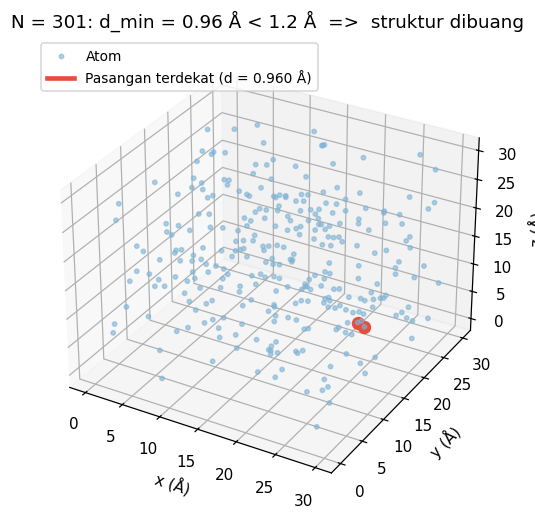

In [2]:
THRESHOLD = 1.2
base = generate_points(300, "uniform", box=(30, 30, 30), seed=SEED)
pts, planted = plant_close_pair(base, distance=0.96, seed=SEED)
d, pair = closest_pair_dc(pts)
verdict = "DIBUANG (struktur tidak valid)" if d < THRESHOLD else "DITERIMA"
print(f"Jarak terdekat = {d:.3f} Å (pasangan {pair}, disisipkan {planted}) | threshold {THRESHOLD} Å -> {verdict}")
fig = viz.plot_points_3d(pts, pair, title=f"N = {len(pts)}: d_min = {d:.2f} Å < {THRESHOLD} Å  =>  struktur dibuang")
plt.show()

## 3. Cara kerja Divide-and-Conquer
Urutkan menurut X, bagi dua, selesaikan tiap sisi (`d1`, `d2`), `d = min(d1, d2)`. Pasangan yang **melintasi** garis pembagi hanya mungkin berada di strip selebar `2d`, jadi hanya strip itu yang diperiksa.
Implementasi iteratif dengan stack buatan (tanpa rekursi Python).

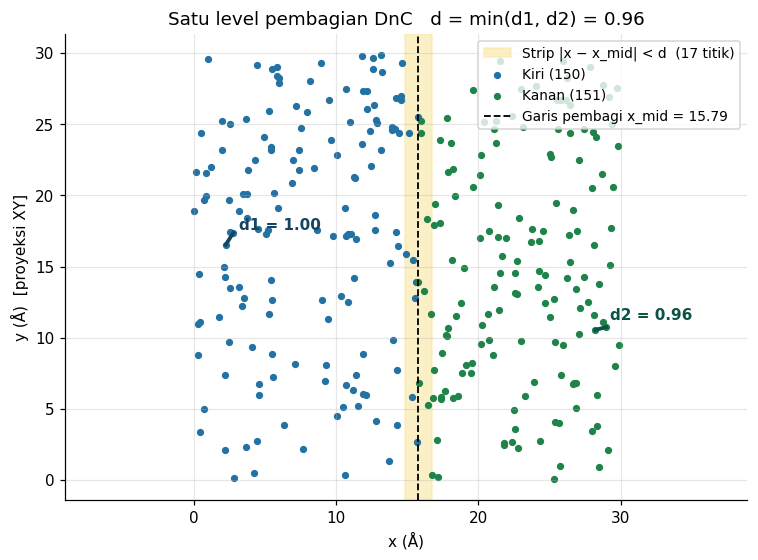

In [3]:
fig = viz.plot_dc_split_2d(pts)
plt.show()

## 4. Verifikasi kebenaran
Semua algoritma dibandingkan dengan KD-tree pada beberapa dataset (termasuk dataset dengan pasangan disisipkan).
Yang dijamin optimal (naive, DnC) harus **BENAR** di mana-mana; greedy 1x diharapkan sering salah.

dataset,clustered-500,lattice-500,planted-301,uniform-500
algorithm,,,,
dc_paper,True,True,True,True
dc_standard,True,True,True,True
greedy_1x,False,False,False,False
greedy_rep,False,False,False,False
kdtree,True,True,True,True
naive,True,True,True,True
naive_vec,True,True,True,True


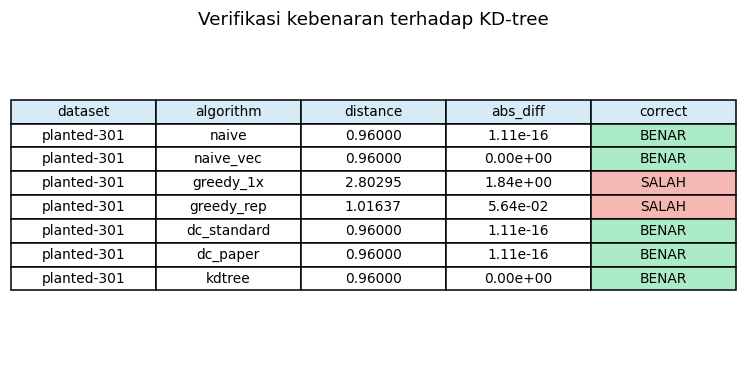

Pasangan konsisten dengan jarak yang dilaporkan: True


In [4]:
datasets = {
    "uniform-500": generate_points(500, "uniform", box_for(500), SEED),
    "clustered-500": generate_points(500, "clustered", box_for(500), SEED),
    "lattice-500": generate_points(500, "lattice_jitter", box_for(500), SEED),
    "planted-301": pts,
}
frames = []
for name, p in datasets.items():
    df_v = verify_correctness(p, ALGOS)
    df_v.insert(0, "dataset", name)
    frames.append(df_v)
verif = pd.concat(frames, ignore_index=True)
display(verif.pivot(index="algorithm", columns="dataset", values="correct"))
fig = viz.plot_correctness_table(verif[verif.dataset == "planted-301"])
plt.show()
print("Pasangan konsisten dengan jarak yang dilaporkan:", bool(verif.pair_consistent.all()))

## 5. Eksperimen skala
N dari 300 sampai 20000 pada tiga distribusi data (kerapatan atom dijaga konstan). Naive murni Python hanya dijalankan sampai `MAX_NAIVE_N`.
Garis putus-putus = acuan teoritis O(n²) dan O(n log n).

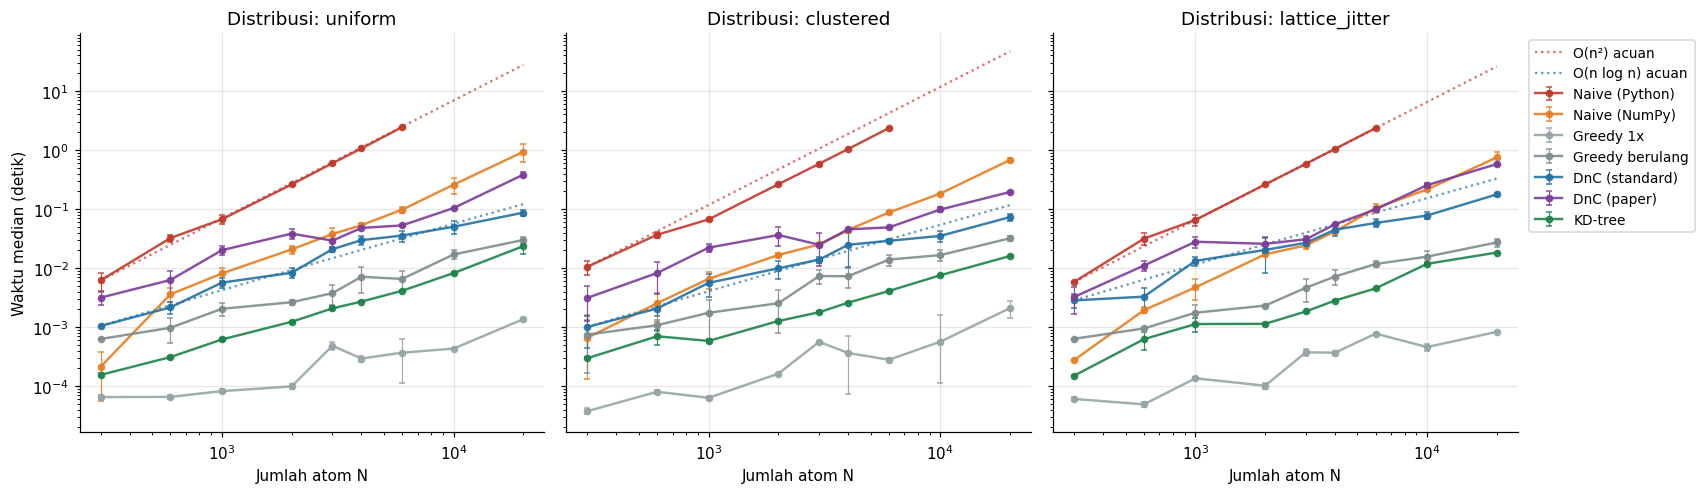

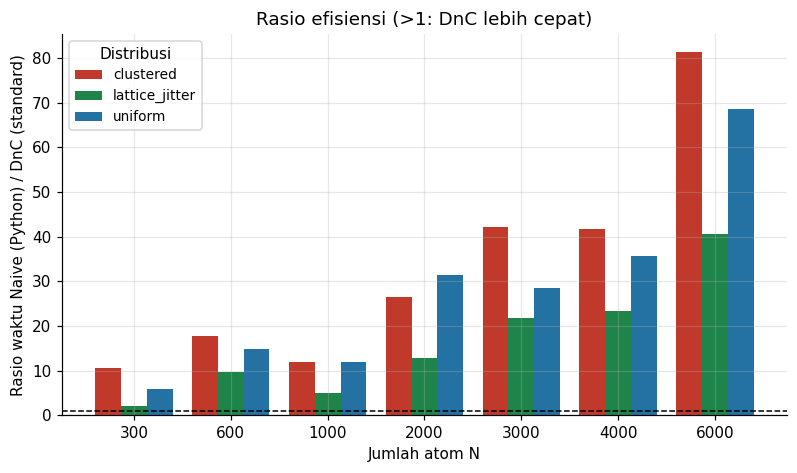

dist,clustered,lattice_jitter,uniform
algorithm,,,
dc_paper,0.1949,0.5784,0.3829
dc_standard,0.0732,0.1772,0.0870
greedy_1x,0.0021,0.0008,0.0014
greedy_rep,0.0320,0.0272,0.0300
kdtree,0.0160,0.0183,0.0235
naive_vec,0.6789,0.7499,0.9332


In [5]:
scaling = pd.concat(
    [run_scaling_experiment(SIZES, dist, ALGOS, repeats=REPEATS, seed=SEED, max_naive_n=MAX_NAIVE_N) for dist in DISTS],
    ignore_index=True,
)
fig = viz.plot_scaling(scaling); plt.show()
fig = viz.plot_speedup(scaling); plt.show()
display(scaling[scaling.n == max(SIZES)].pivot(index="algorithm", columns="dist", values="median_time").round(4))

## 6. Akurasi greedy
Greedy berulang dengan titik awal acak berbeda, diambil minimumnya (analog Fig. 6). Pertanyaannya: berapa pengulangan agar mendekati akurat, dan apakah masih lebih cepat dari DnC?

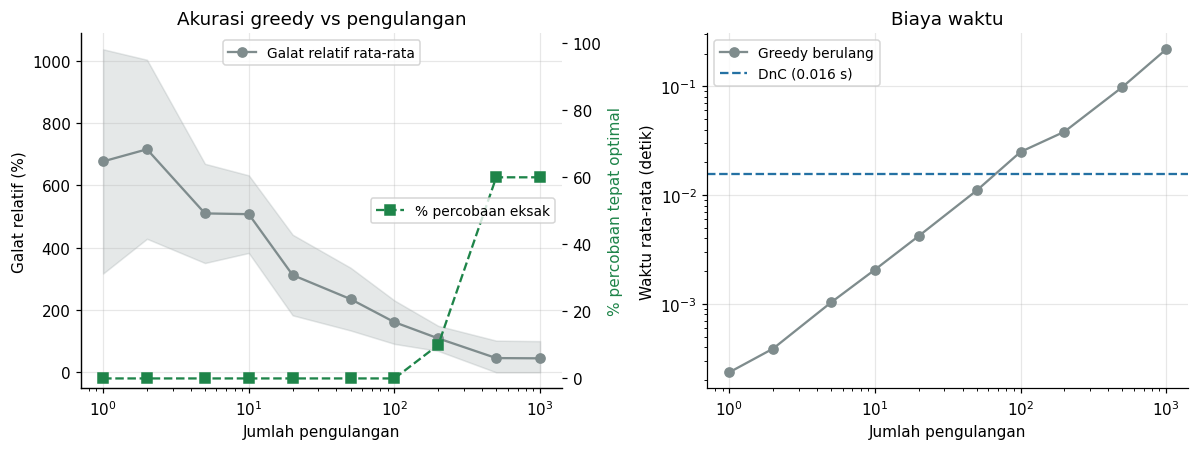

,repeats,mean_rel_error_pct,std_rel_error_pct,frac_exact,mean_time,lebih_cepat_dari_DnC
0,1,677.07,359.74,0.0,0.0002,True
1,2,715.96,287.30,0.0,0.0004,True
2,5,510.13,159.21,0.0,0.0010,True
3,10,507.71,124.50,0.0,0.0021,True
4,20,312.35,129.31,0.0,0.0042,True
5,50,235.03,100.65,0.0,0.0110,True
6,100,161.07,69.69,0.0,0.0250,False
7,200,108.95,40.21,0.1,0.0382,False
8,500,45.74,56.02,0.6,0.0984,False
9,1000,44.99,55.10,0.6,0.2189,False


Waktu DnC pada N = 3856: 0.0155 s


In [6]:
gpts = generate_points(GREEDY_N, "uniform", box_for(GREEDY_N), SEED)
acc = run_greedy_accuracy(gpts, GREEDY_REPEATS, trials=GREEDY_TRIALS)
dc_t = time_function(closest_pair_dc, gpts, repeats=3).median
fig = viz.plot_greedy_convergence(acc, dc_time=dc_t); plt.show()
acc["lebih_cepat_dari_DnC"] = acc.mean_time < dc_t
display(acc.round({"mean_rel_error_pct": 2, "std_rel_error_pct": 2, "frac_exact": 2, "mean_time": 4}))
print(f"Waktu DnC pada N = {GREEDY_N}: {dc_t:.4f} s")

## 7. Pengaruh distribusi data dan rasio pembagian
**Ukuran strip** per level menjelaskan mengapa waktu DnC tidak monoton di paper (dataset 6 lebih lambat dari dataset yang lebih besar): strip besar berarti lebih banyak pekerjaan.

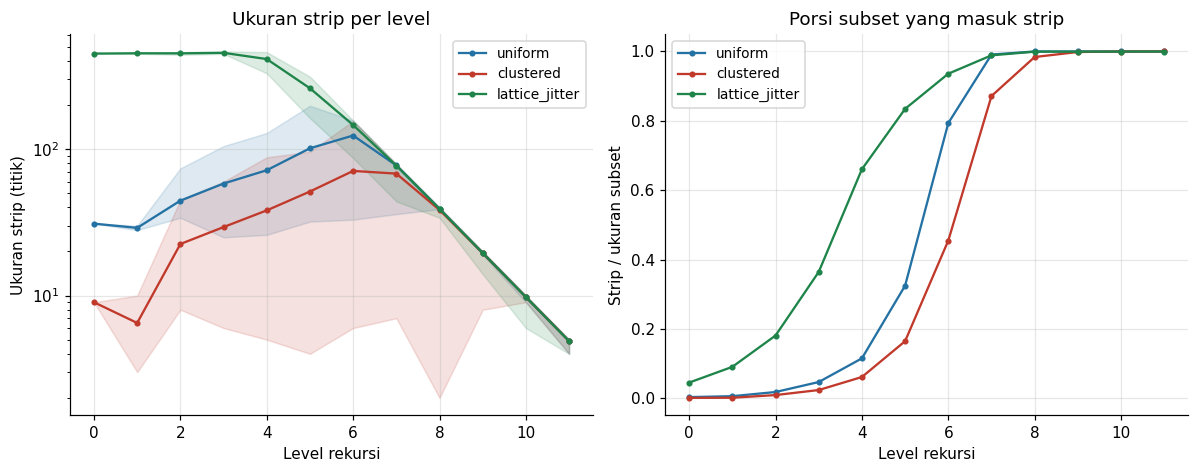

,uniform,clustered,lattice_jitter
kedalaman maks,12.0,12.0,12.0
jumlah hitung jarak,59527.0,38180.0,271056.0
strip rata-rata,15.4,13.6,19.8
strip maks,198.0,156.0,465.0


In [7]:
stats_by_dist = {}
for dist in DISTS:
    p = generate_points(STRIP_N, dist, box_for(STRIP_N), SEED)
    _, stats_by_dist[dist] = closest_pair_dc(p, return_stats=True)
fig = viz.plot_strip_sizes(stats_by_dist); plt.show()
display(pd.DataFrame({k: {"kedalaman maks": v["max_depth"], "jumlah hitung jarak": v["n_distance_computations"],
                          "strip rata-rata": round(v["strip_overall"]["mean"], 1), "strip maks": v["strip_overall"]["max"]}
                      for k, v in stats_by_dist.items()}))

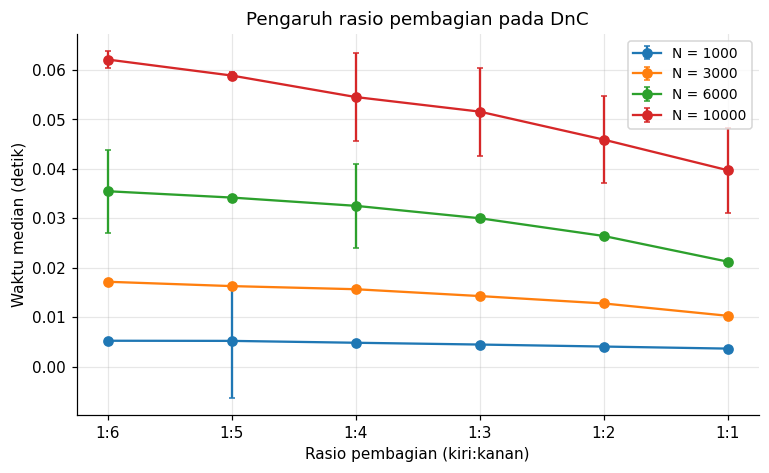

n,1000,3000,6000,10000
ratio,,,,
1:1,0.0036,0.0103,0.0212,0.0397
1:2,0.0040,0.0128,0.0264,0.0459
1:3,0.0044,0.0143,0.0300,0.0516
1:4,0.0048,0.0156,0.0325,0.0545
1:5,0.0052,0.0163,0.0342,0.0589
1:6,0.0052,0.0172,0.0355,0.0621


In [8]:
pts_by_size = {n: generate_points(n, "uniform", box_for(n), SEED) for n in RATIO_SIZES}
ratio_df = run_split_ratio_experiment(pts_by_size, repeats=REPEATS)
fig = viz.plot_split_ratio(ratio_df); plt.show()
display(ratio_df.pivot(index="ratio", columns="n", values="median_time").round(4))

## 8. Ringkasan

In [9]:
N_TOP = max(SIZES)
top = scaling[(scaling.n == N_TOP) & (scaling["dist"] == "uniform")].set_index("algorithm")
naive_n = scaling[(scaling.algorithm == "naive") & (scaling["dist"] == "uniform")].n.max()
naive_t = scaling[(scaling.algorithm == "naive") & (scaling["dist"] == "uniform") & (scaling.n == naive_n)].median_time.iloc[0]
info = {
    "naive":       ("O(n²)",          "Ya",    "Python murni; N terbesar yang dijalankan = %d (%.2f s)" % (naive_n, naive_t)),
    "naive_vec":   ("O(n²)",          "Ya",    "NumPy: tanpa loop Python, masih kuadratik"),
    "greedy_1x":   ("O(n²) terburuk", "Tidak", "Cepat, tetapi sering salah"),
    "greedy_rep":  ("O(r·n²) terburuk", "Tidak", "20 pengulangan; tetap tidak dijamin"),
    "dc_standard": ("O(n log n)*",    "Ya",    "*urut strip menambah faktor log; iteratif"),
    "dc_paper":    ("tak terjamin O(n log n)", "Ya", "strip X-Y-Z + brute force, lebih lambat dari standard"),
    "kdtree":      ("O(n log n)",     "Ya",    "Baseline modern, ground truth"),
}
def slope(algo, nmin=1000):
    # Eksponen empiris: kemiringan log-log waktu vs N (rata-rata tiga distribusi)
    out = []
    for dist in DISTS:
        d_ = scaling[(scaling.algorithm == algo) & (scaling["dist"] == dist) & (scaling.n >= nmin)]
        if len(d_) >= 3:
            out.append(np.polyfit(np.log(d_.n), np.log(d_.median_time), 1)[0])
    return round(float(np.mean(out)), 2) if out else "-"

summary = pd.DataFrame(
    [{"algoritma": a, "kompleksitas teoritis": c, "optimal terjamin": g,
      f"waktu N={N_TOP} (s)": (round(top.loc[a, "median_time"], 4) if a in top.index else "dilewati"),
      "benar": (bool(top.loc[a, "correct"]) if a in top.index else "-"),
      "eksponen empiris": slope(a), "catatan": n}
     for a, (c, g, n) in info.items()]
)
display(summary)

,algoritma,kompleksitas teoritis,optimal terjamin,waktu N=20000 (s),benar,eksponen empiris,catatan
0,naive,O(n²),Ya,dilewati,-,2.00,Python murni; N terbesar yang dijalankan = 600...
1,naive_vec,O(n²),Ya,0.9332,True,1.60,"NumPy: tanpa loop Python, masih kuadratik"
2,greedy_1x,O(n²) terburuk,Tidak,0.0014,False,0.85,"Cepat, tetapi sering salah"
3,greedy_rep,O(r·n²) terburuk,Tidak,0.03,False,0.98,20 pengulangan; tetap tidak dijamin
4,dc_standard,O(n log n)*,Ya,0.087,True,0.88,*urut strip menambah faktor log; iteratif
5,dc_paper,tak terjamin O(n log n),Ya,0.3829,True,0.92,"strip X-Y-Z + brute force, lebih lambat dari s..."
6,kdtree,O(n log n),Ya,0.0235,True,1.12,"Baseline modern, ground truth"


### Kesimpulan
- **Kebenaran**: naive, naive NumPy, DnC (kedua `strip_mode`) dan KD-tree memberi jarak identik pada semua dataset uji. Greedy (1x maupun 20x) salah pada semua dataset uji.
- **DnC vs naive Python**: DnC 8 sampai 77 kali lebih cepat pada N 300 sampai 6000 (paper: 3.5 sampai 231). Rasio naik dengan N dan bervariasi menurut distribusi data, sesuai arah klaim paper.
- **Baseline yang adil mengubah cerita**: naive versi NumPy dan terutama KD-tree jauh lebih cepat dari DnC Python murni pada N kecil sampai menengah. DnC baru menyusul naive NumPy sekitar N = 10⁴ dan tetap kalah dari KD-tree. Keunggulan DnC di paper sebagian besar berasal dari pembandingnya, naive Python murni.
- **Greedy**: paling cepat, tetapi tidak andal. Pada N = 3856, 1000 pengulangan pun hanya menemukan pasangan optimal pada sekitar 60% percobaan, dan mulai lebih lambat dari DnC setelah sekitar 100 pengulangan. Klaim "greedy paling efisien" hanya berlaku bila hasil salah diterima.
- **Distribusi data dan rasio**: strip DnC paling besar pada `lattice_jitter` (mirip MOF simetris) karena banyak titik berbagi koordinat X hampir sama. Itu menjelaskan waktu DnC yang tidak monoton di paper. Rasio pembagian 1:1 tercepat, sesuai Fig. 8. Strip "paper" (filter X-Y-Z lalu brute force) lebih lambat dari strip standard.
- **Teori**: recurrence paper T(n) = 2T(n/2) + k (konstan) sebenarnya menghasilkan O(n), bukan O(n log n). O(n log n) benar bila langkah strip O(n). Eksponen empiris pada tabel di atas mendukung kesimpulan DnC mendekati kuasi-linear, jauh di bawah 2 milik naive.

## 9. (Opsional) Dataset asli: `pcl` (3856 atom)
CIF `data/pcl_v1-on15-3D_1-oe107.cif` = dataset No. 8 di paper (3856 atom). Jarak lintas batas periodik tidak dihitung, sama seperti paper.

N = 3856 atom (C, Cu, H, N); paper (i5-8250U): naive 39.255 s, DnC 0.782 s, greedy 0.02 s


,algoritma,jarak (Å),waktu (s)
0,naive,0.17925,0.9482
1,naive_vec,0.17925,0.0423
2,greedy_1x,1.08419,0.0004
3,greedy_rep,0.62815,0.0089
4,dc_standard,0.17925,0.0238
5,dc_paper,0.17925,0.0428
6,kdtree,0.17925,0.0022


Pasangan terdekat: (963, 1901) ['C', 'C'] 0.1792 Å


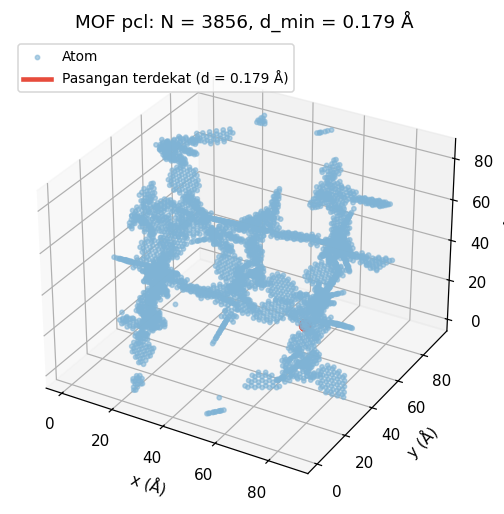

In [10]:
from pathlib import Path
CIF = Path("data/pcl_v1-on15-3D_1-oe107.cif")
if CIF.exists():
    cif_pts, cif_sym = load_cif(CIF, return_symbols=True)
    rows = []
    for name, fn in ALGOS.items():
        t = time_function(fn, cif_pts, repeats=1 if name == "naive" else 3, warmup=0 if name == "naive" else 1)
        rows.append({"algoritma": name, "jarak (Å)": round(t.result[0], 5), "waktu (s)": round(t.median, 4)})
    cif_df = pd.DataFrame(rows)
    print(f"N = {len(cif_pts)} atom ({', '.join(sorted(set(cif_sym)))}); paper (i5-8250U): naive 39.255 s, DnC 0.782 s, greedy 0.02 s")
    display(cif_df)
    truth, tpair = closest_pair_kdtree(cif_pts)
    print("Pasangan terdekat:", tpair, [cif_sym[i] for i in tpair], f"{truth:.4f} Å")
    fig = viz.plot_points_3d(cif_pts, tpair, title=f"MOF pcl: N = {len(cif_pts)}, d_min = {truth:.3f} Å"); plt.show()
else:
    print("File CIF tidak ditemukan, bagian ini dilewati.")